In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import random_split, DataLoader
from torchvision import datasets, transforms
import sys
sys.path.append('..')
from training.model import MNISTClassifier

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

full_dataset = datasets.MNIST(root='../data', train=True, download=False, transform=transform)
train_size = int(0.8 * len(full_dataset))
val_size   = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False)

In [3]:
def train_with_lr(lr, epochs=10):
    model     = MNISTClassifier()
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    val_accs = []

    for epoch in range(1, epochs + 1):
        # Training
        model.train()
        for images, labels in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(images), labels)
            loss.backward()
            optimizer.step()

        # Validation
        model.eval()
        correct = 0
        with torch.no_grad():
            for images, labels in val_loader:
                correct += (model(images).argmax(1) == labels).sum().item()

        acc = correct / len(val_dataset)
        val_accs.append(acc)
        print(f"LR={lr} | Epoch {epoch} | Val Acc: {acc:.4f}")

    return val_accs

In [4]:
learning_rates = [0.1, 0.01, 0.001, 0.0001]
results = {}

for lr in learning_rates:
    print(f"\n--- Training with LR={lr} ---")
    results[lr] = train_with_lr(lr, epochs=10)


--- Training with LR=0.1 ---
LR=0.1 | Epoch 1 | Val Acc: 0.1104
LR=0.1 | Epoch 2 | Val Acc: 0.1104
LR=0.1 | Epoch 3 | Val Acc: 0.0983
LR=0.1 | Epoch 4 | Val Acc: 0.1104
LR=0.1 | Epoch 5 | Val Acc: 0.1104
LR=0.1 | Epoch 6 | Val Acc: 0.0994
LR=0.1 | Epoch 7 | Val Acc: 0.0997
LR=0.1 | Epoch 8 | Val Acc: 0.1071
LR=0.1 | Epoch 9 | Val Acc: 0.1104
LR=0.1 | Epoch 10 | Val Acc: 0.1104

--- Training with LR=0.01 ---
LR=0.01 | Epoch 1 | Val Acc: 0.9190
LR=0.01 | Epoch 2 | Val Acc: 0.9327
LR=0.01 | Epoch 3 | Val Acc: 0.9233
LR=0.01 | Epoch 4 | Val Acc: 0.9374
LR=0.01 | Epoch 5 | Val Acc: 0.9327
LR=0.01 | Epoch 6 | Val Acc: 0.9306
LR=0.01 | Epoch 7 | Val Acc: 0.9299
LR=0.01 | Epoch 8 | Val Acc: 0.9422
LR=0.01 | Epoch 9 | Val Acc: 0.9394
LR=0.01 | Epoch 10 | Val Acc: 0.9393

--- Training with LR=0.001 ---
LR=0.001 | Epoch 1 | Val Acc: 0.9555
LR=0.001 | Epoch 2 | Val Acc: 0.9643
LR=0.001 | Epoch 3 | Val Acc: 0.9703
LR=0.001 | Epoch 4 | Val Acc: 0.9702
LR=0.001 | Epoch 5 | Val Acc: 0.9750
LR=0.001 |

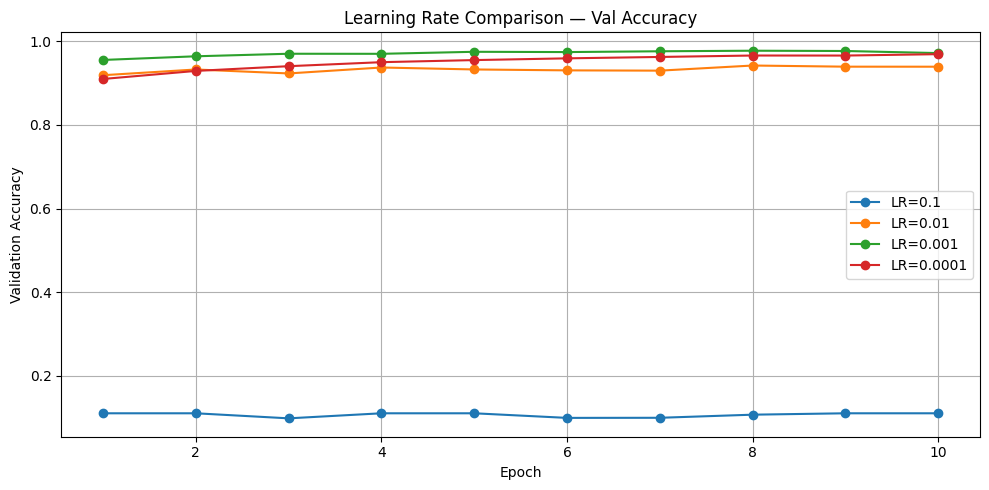

In [5]:
plt.figure(figsize=(10, 5))

for lr, accs in results.items():
    plt.plot(range(1, 11), accs, marker='o', label=f"LR={lr}")

plt.title("Learning Rate Comparison — Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
print("=" * 45)
print(f"{'LR':<10} | {'Best Val Acc':<15} | Verdict")
print("=" * 45)
verdicts = {
    0.1:    "Too high  — unstable",
    0.01:   "Good      — fast convergence",
    0.001:  "Best      — stable & accurate ",
    0.0001: "Too low   — slow convergence",
}
for lr, accs in results.items():
    print(f"{str(lr):<10} | {max(accs):.4f}          | {verdicts[lr]}")
print("=" * 45)

LR         | Best Val Acc    | Verdict
0.1        | 0.1104          | Too high  — unstable
0.01       | 0.9422          | Good      — fast convergence
0.001      | 0.9776          | Best      — stable & accurate ✅
0.0001     | 0.9693          | Too low   — slow convergence
